## Introduction
딥러닝 관련 논문을 읽으며 공부하다 보면 대부분의 논문 구현이 PyTorch(torch) 기반으로 되어 있음을 알 수 있다. 아래 그래프에서 볼 수 있듯이 2024년 기준 PyTorch, TensorFlow, JAX 중 PyTorch를 사용한 프로젝트가 제일 많은 비중을 차지하는 것을 볼 수 있다 [[1]](https://softwaremill.com/ml-engineer-comparison-of-pytorch-tensorflow-jax-and-flax/).   

![image.png](https://softwaremill.com/user/pages/blog/229.ml-engineer-comparison-of-pytorch-tensorflow-jax-and-flax/image2.png?g-1efd1e18)

### 1.1. Tensor Slicing이란?
텐서 슬라이싱은 다차원 배열에서 원하는 부분만 선택적으로 추출하는 연산으로 NumPy의 배열 인덱싱에서 유래했고 PyTorch도 동일한 문법을 사용한다 (NumPy-like).

### 1.2. 왜 필요한가?
딥러닝에서 텐서는 보통 (B, H, W, C) 같은 고차원 구조를 가진다. 모델 내부에서 특정 배치만, 특정 채널만, 특정 공간 위치만 꺼내서 연산해야 할 일이 매우 많다. 슬라이싱 없이는 불필요한 데이터까지 복사하거나 반복문으로 순회해야 하는데, 슬라이싱은 이걸 뷰(view) 방식으로 해결한다.

### 1.3. 원리
핵심은 "메모리를 복사하지 않는다"는 것이다.

텐서는 내부적으로 두 가지로 구성되는데:
- storage: 실제 데이터가 1D로 연속 저장된 메모리
- stride + offset: "몇 칸 건너뛰면 다음 원소인지"를 기술하는 메타데이터

슬라이싱을 하면 storage는 그대로 두고 stride와 offset만 바꾼 새 텐서 객체를 반환하기 때문에 빠르고 메모리 효율적이다 [[2]](https://docs.pytorch.org/docs/stable/tensor_view.html).



In [1]:
import torch
import matplotlib.pyplot as plt

In [2]:
t = torch.zeros(3, 3, 3, 3)  # (B, H, W, C)

print(t[0].shape)
print(t[:, 1, :, :].shape)
print(t[..., 0].shape)
print(t[0:2].shape)

torch.Size([3, 3, 3])
torch.Size([3, 3, 3])
torch.Size([3, 3, 3])
torch.Size([2, 3, 3, 3])


In [3]:
print(t.stride())
print(t[0].stride())
print(t[:, 1].stride())
t_slice = t[0]
print(t_slice.data_ptr() == t.data_ptr())

(27, 9, 3, 1)
(9, 3, 1)
(27, 3, 1)
True


## 2. Method
본 글에서는 사람들의 이해를 돕기 위해 matplotlib로 시각화한다. Computer Vision 영역에서 제일 많이 사용되는 4D [B, H, W, C] 형태를 시각화 할 것이며, [3,3,3,3] 사이즈의 boolean 자료형의 입력을 사용한다. 이때 B는 batch 사이즈이고, H는 이미지의 높이, W는 이미지의 너비, C는 RGB로 판단한다. 따라서 $3^2$ 크기의 컬러 이미지 3개가 있는 상황이다.

기본적으로 ```tensor.zeros().dtype(bool)``` 로 4차원 False tensor를 생성하여 슬라이싱 되는 부분만 True로 변환하여 어떤 부분이 슬라이싱 되는지 시각화한다.

우리들의 천하무적 클로드가 ```visualize_tensor()```라는 시각화 코드를 만들어줬다:

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

RGB_COLORS = ['red', 'green', 'blue']
RGB_LABELS = ['R', 'G', 'B']

def draw_cube(ax, x, y, z, filled=False, color='steelblue'):
    vertices = np.array([
        [x,   y,   z],   [x+1, y,   z],   [x+1, y+1, z],   [x,   y+1, z],
        [x,   y,   z+1], [x+1, y,   z+1], [x+1, y+1, z+1], [x,   y+1, z+1],
    ])
    faces = [
        [vertices[0], vertices[1], vertices[2], vertices[3]],
        [vertices[4], vertices[5], vertices[6], vertices[7]],
        [vertices[0], vertices[1], vertices[5], vertices[4]],
        [vertices[2], vertices[3], vertices[7], vertices[6]],
        [vertices[0], vertices[3], vertices[7], vertices[4]],
        [vertices[1], vertices[2], vertices[6], vertices[5]],
    ]
    if filled:
        poly = Poly3DCollection(faces, alpha=0.5,
                                facecolor=color, edgecolor='black', linewidth=0.5)
    else:
        poly = Poly3DCollection(faces, alpha=0.03,
                                facecolor='white', edgecolor='gray', linewidth=0.3, linestyle='--')
    ax.add_collection3d(poly)


def visualize_tensor(tensor):
    if hasattr(tensor, 'numpy'):
        arr = tensor.numpy().astype(bool)
    else:
        arr = np.asarray(tensor, dtype=bool)

    assert arr.shape == (3, 3, 3, 3), "Input must be [3,3,3,3]"
    B, H, W, C = arr.shape

    fig = plt.figure(figsize=(5 * B, 6))

    for b in range(B):
        ax = fig.add_subplot(1, B, b + 1, projection='3d')

        for h in range(H):
            for w in range(W):
                for c in range(C):
                    draw_cube(ax, w, c, h,
                              filled=bool(arr[b, h, w, c]),
                              color=RGB_COLORS[c])  # c=0→R, c=1→G, c=2→B

        ax.set_xlabel('C', labelpad=6)
        ax.set_ylabel('W', labelpad=6)
        ax.set_zlabel('H', labelpad=6)

        ticks  = [0.5, 1.5, 2.5]
        ax.set_xticks(ticks); ax.set_xticklabels(RGB_LABELS, fontsize=7)  # R/G/B 표기
        ax.set_yticks(ticks); ax.set_yticklabels(['1', '2', '3'], fontsize=7)
        ax.set_zticks(ticks); ax.set_zticklabels(['1', '2', '3'], fontsize=7)

        ax.set_xlim(0, C); ax.set_ylim(0, W); ax.set_zlim(0, H)
        ax.set_title(f'B={b+1}', fontsize=11)
        ax.view_init(elev=20, azim=-60)

    # Legend: R/G/B + False
    patches = [mpatches.Patch(facecolor=c, edgecolor='black', label=f'True ({l})')
               for c, l in zip(RGB_COLORS, RGB_LABELS)]
    patches.append(mpatches.Patch(facecolor='white', edgecolor='gray', label='False', linestyle='--'))
    fig.legend(handles=patches, loc='lower center',
               ncol=4, fontsize=9, frameon=True, bbox_to_anchor=(0.5, 0.0))

    plt.suptitle('[B, H, W, C] Tensor Slice Visualization', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

전체 체크

/tmp/ipykernel_32917/2928474660.py:73: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


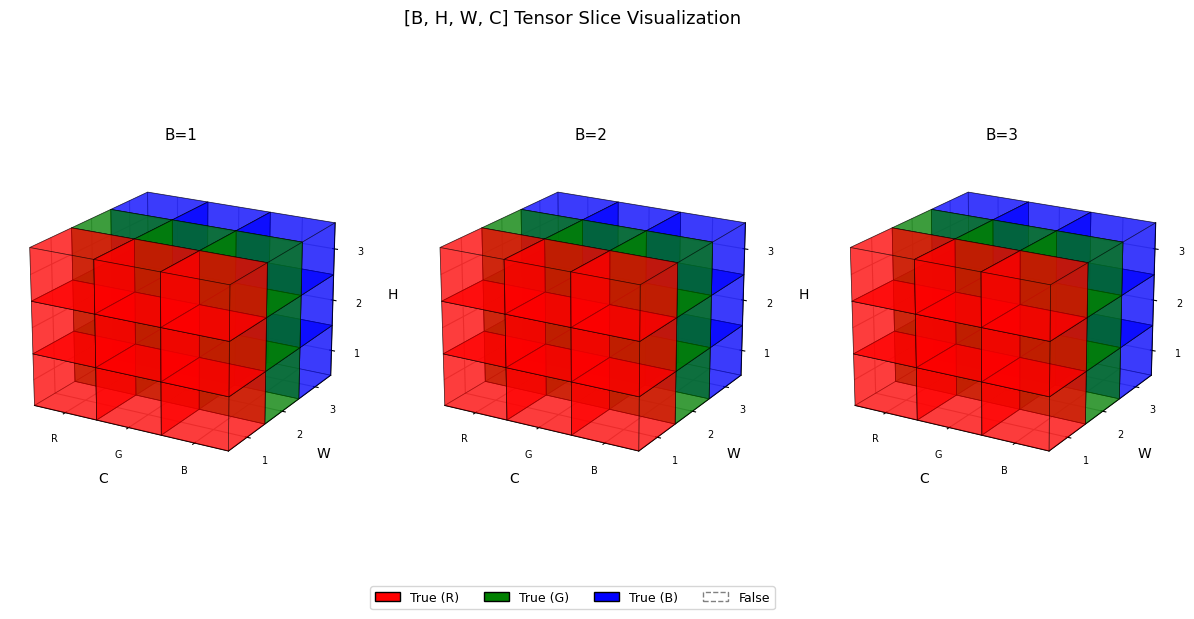

In [5]:
t1 = torch.ones([3,3,3,3], dtype=bool)
visualize_tensor(t1)

두번째 이미지만 슬라이싱

/tmp/ipykernel_32917/2928474660.py:73: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


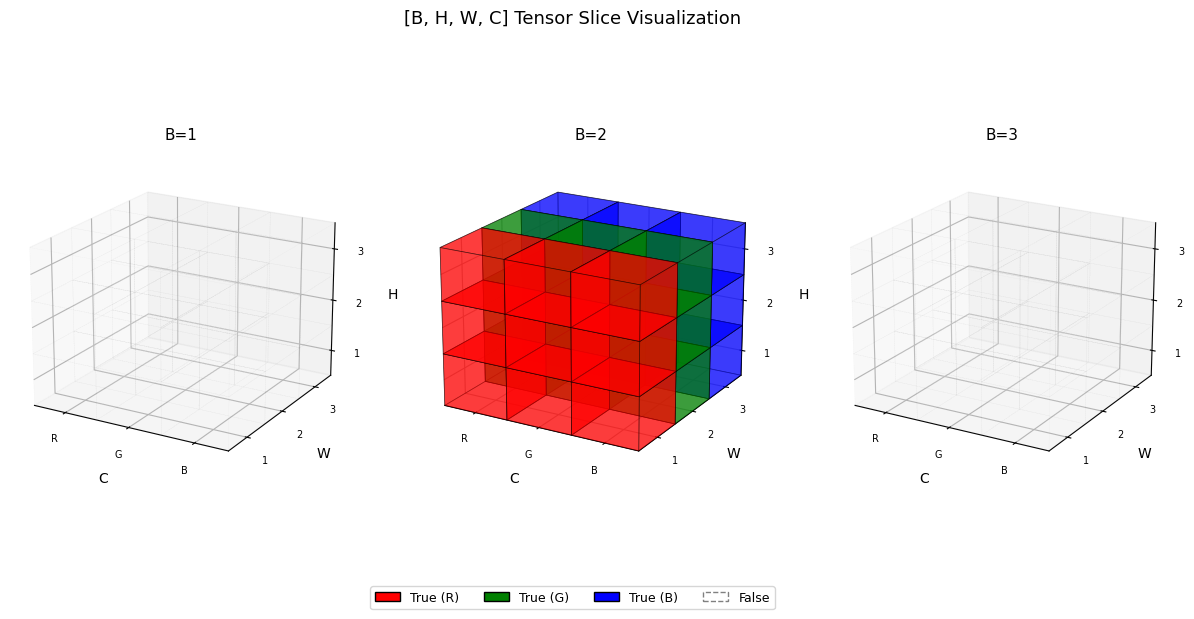

In [6]:
t = torch.zeros([3,3,3,3], dtype=bool)
t[1,:,:,:] = True
visualize_tensor(t)

RGB 중 G만 시각화   
```...```(Ellipsis)는 "나머지 차원은 전부 : 로 채워줘" 라는 뜻이다.

/tmp/ipykernel_32917/2928474660.py:73: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


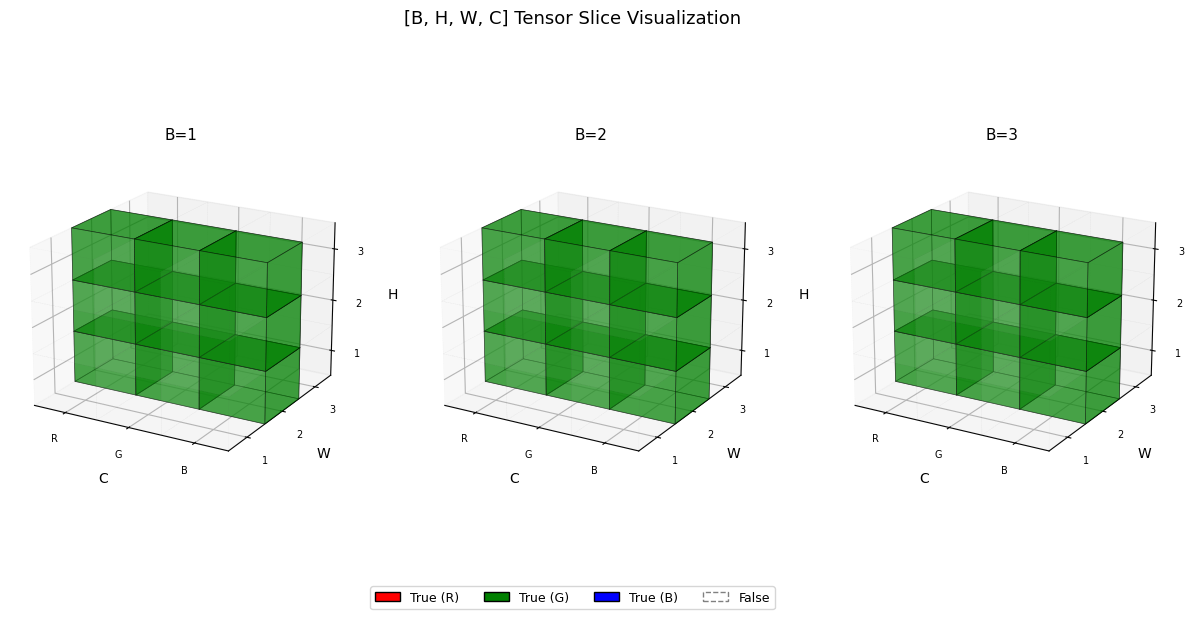

/tmp/ipykernel_32917/2928474660.py:73: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


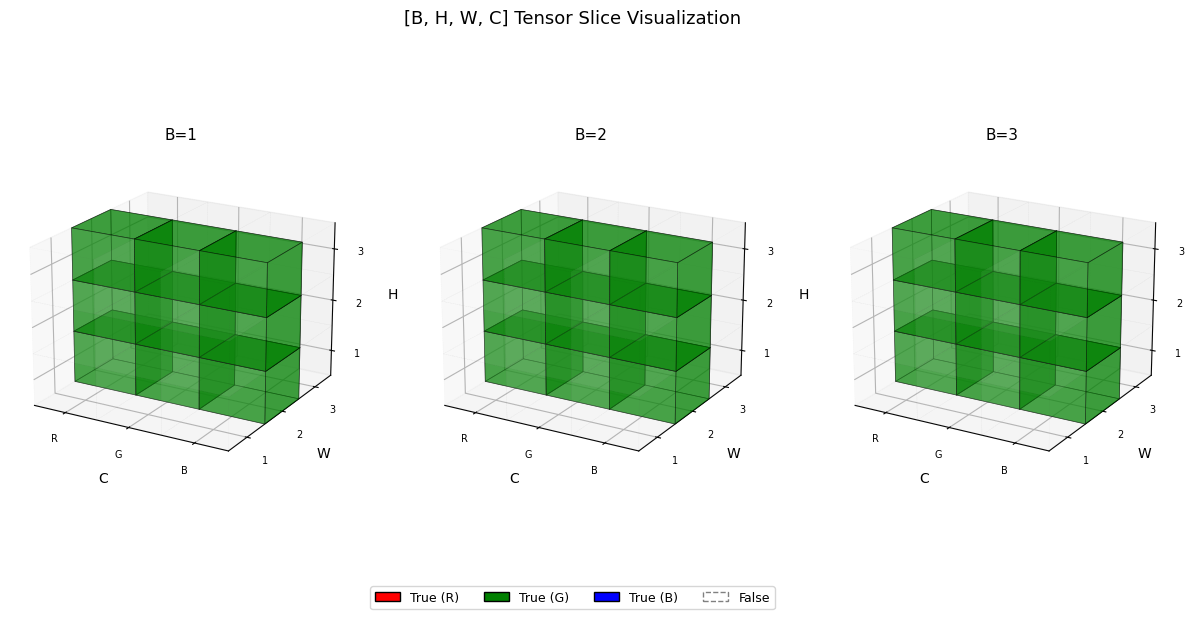

In [7]:
t = torch.zeros([3,3,3,3], dtype=bool)
t[:,:,:,1] = True
visualize_tensor(t)

t = torch.zeros([3,3,3,3], dtype=bool)
t[...,1] = True
visualize_tensor(t)

십자가 모양으로 슬라이싱

/tmp/ipykernel_32917/2928474660.py:73: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


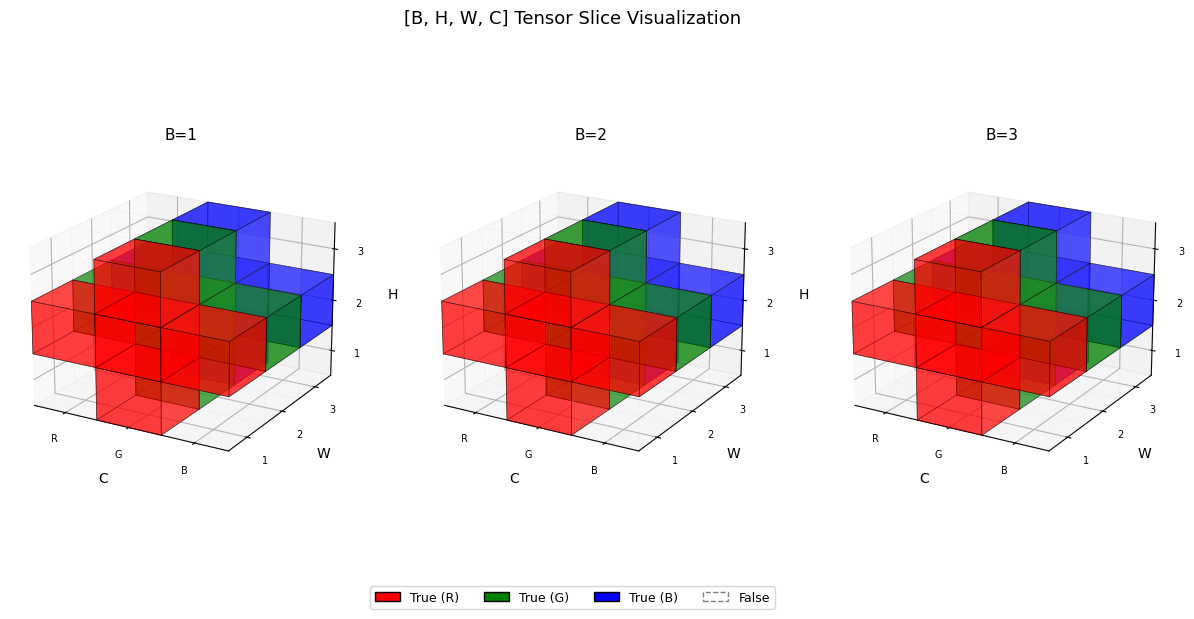

In [8]:
t = torch.zeros([3,3,3,3], dtype=bool)

t[:,1,...] = True
t[...,1,:] = True

visualize_tensor(t)

중심 부분만 슬라이싱

/tmp/ipykernel_32917/2928474660.py:73: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


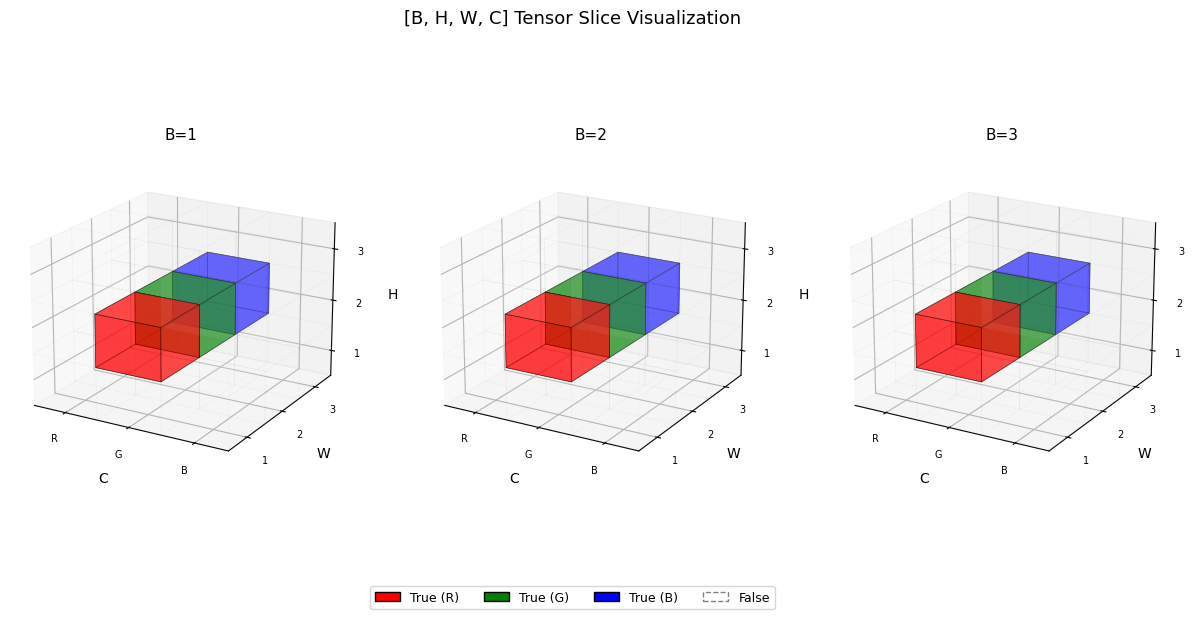

In [9]:
t = torch.zeros([3,3,3,3], dtype=bool)

t[:,1,1,:] = True

visualize_tensor(t)

멋지게 인덱싱 해보기

/tmp/ipykernel_32917/2928474660.py:73: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


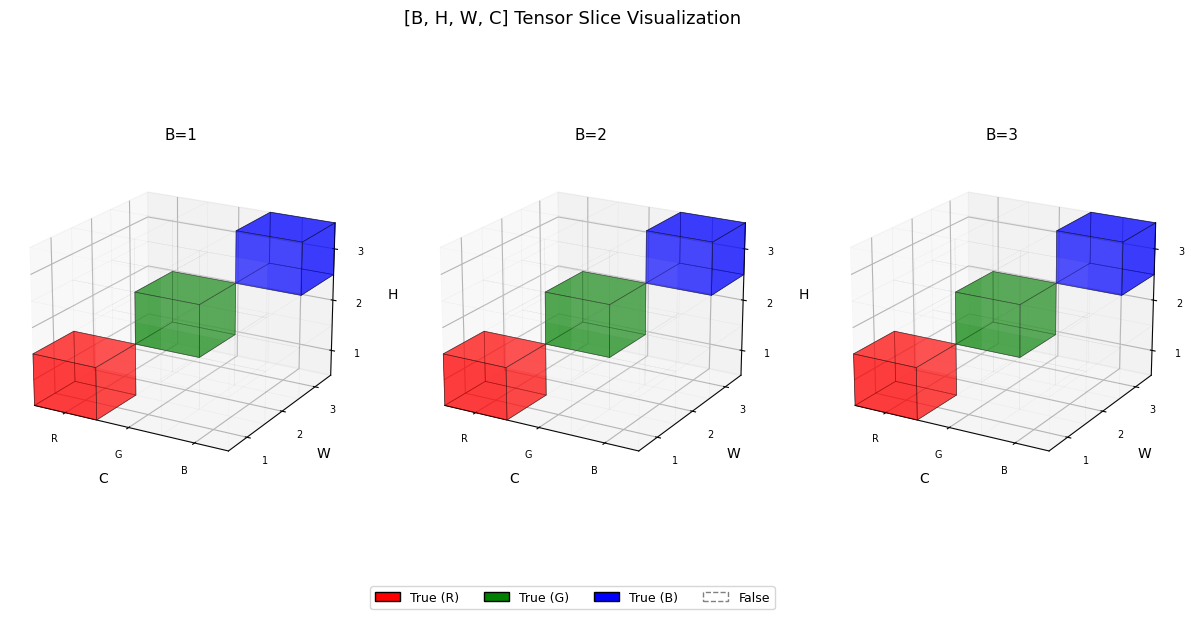

/tmp/ipykernel_32917/2928474660.py:73: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


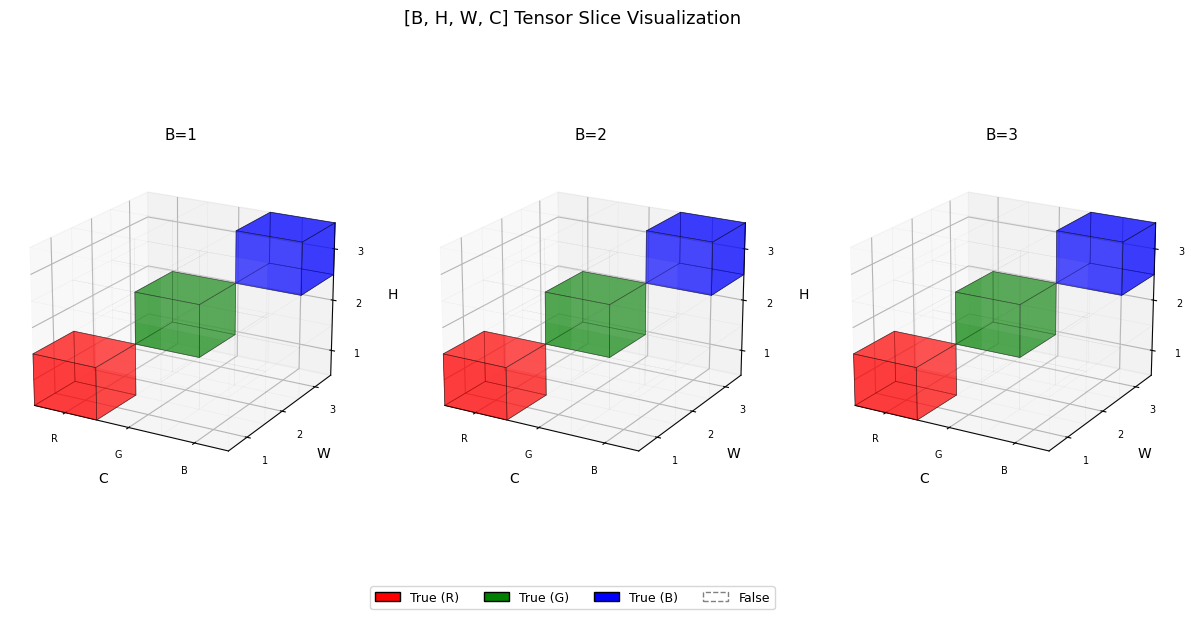

In [10]:
# 안 멋진 방법
t = torch.zeros([3,3,3,3], dtype=bool)

t[:,0,0,0] = True
t[:,1,1,1] = True
t[:,2,2,2] = True

visualize_tensor(t)

# 멋진 방법
t = torch.zeros([3,3,3,3], dtype=bool)

idx = torch.arange(3)
t[:, idx, idx, idx] = True  # H=W=C 인 대각선

visualize_tensor(t)

/tmp/ipykernel_32917/2928474660.py:73: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


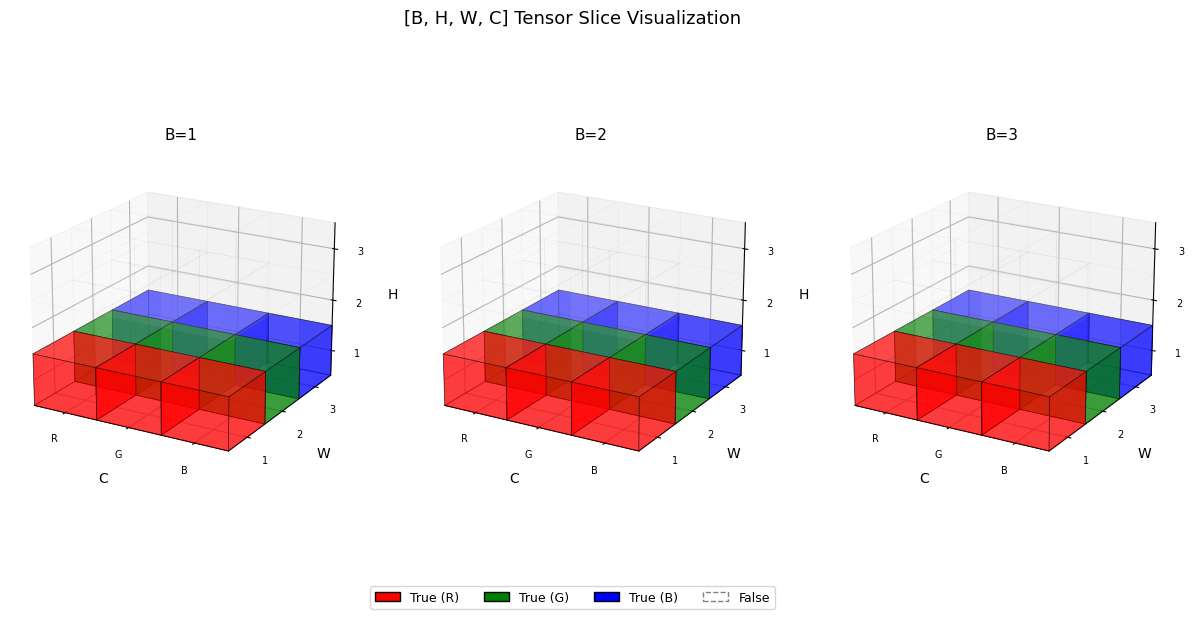

/tmp/ipykernel_32917/4129124184.py:6: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4480.)
  t = t.T
/tmp/ipykernel_32917/2928474660.py:73: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


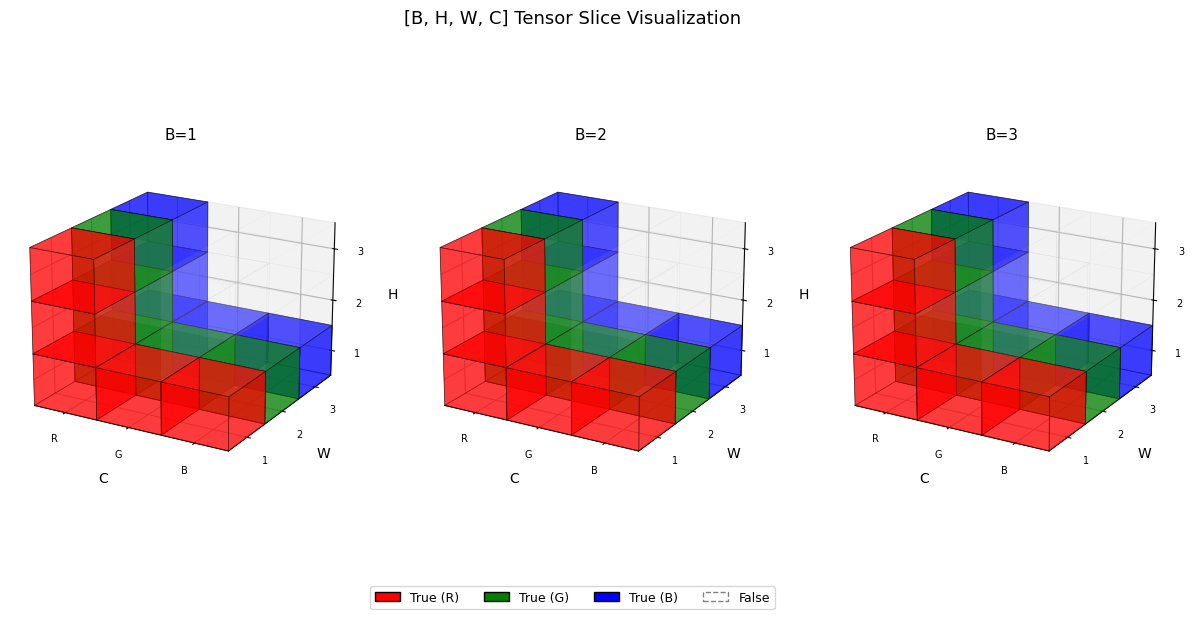

In [11]:
t = torch.zeros([3,3,3,3], dtype=bool)

t[:, 0] = True # R채널만, shape [B, H, W]
visualize_tensor(t)

t = t.T
t[:, 0] = True # R채널만, shape [B, H, W]

visualize_tensor(t)

## 3. `contiguous()`에 대하여

### 메모리 레이아웃부터 이해하기

PyTorch 텐서는 내부적으로 **1D 메모리(storage)** 위에 존재한다. 예를 들어 shape `[2, 3]` 텐서는 실제로 메모리에 이렇게 저장된다:
```
메모리: [a, b, c, d, e, f]
         ↕
tensor([[a, b, c],
        [d, e, f]])
```

이때 "다음 원소로 가려면 몇 칸 건너뛰어야 하는가"를 **stride**라고 한다.

In [12]:
import torch

t = torch.tensor([[1,2,3],[4,5,6]])
print(t.stride())  # (3, 1) → 행 이동시 3칸, 열 이동시 1칸

(3, 1)


### 슬라이싱 후 stride가 꼬이는 상황

이 슬라이싱은 **메모리를 복사하지 않고** stride/offset만 바꿔서 반환한다.
그 결과 메모리 상에서 원소들이 **띄엄띄엄** 놓이게 된다.

stride의 마지막 값이 1이 아니라는 건, 메모리에서 원소들이 연속적으로 붙어있지 않다는 뜻이다.

In [13]:
t = torch.zeros(3, 3, 3, 3)
t_slice = t[:, :, :, 1]   # C 채널 중 G만 추출 → shape [3,3,3]

print(t.stride())               # (27, 9, 3, 1)
print(t_slice.stride())         # (27, 9, 3)  ← 마지막이 1이 아님!
print(t_slice.is_contiguous())  # False

(27, 9, 3, 1)
(27, 9, 3)
False


### 언제 문제가 터지나?

`view()`는 메모리가 연속적으로 배치되어 있다고 가정한다. 그래서 비연속 텐서에 `.view()`를 쓰면 에러가 발생한다.

In [14]:
t = torch.rand([1,2,2,2])

# transpose/permute는 stride 관계가 틀어져서 진짜 에러 발생
t_transposed = t.transpose(1, 2)  # stride 관계가 깨짐
print(t_transposed.is_contiguous())  # False

try:
    t_transposed.view(-1)
except RuntimeError as e:
    print(e)

# 해결
print(t_transposed.contiguous().view(-1))
print(t_transposed.reshape(-1))

False
view size is not compatible with input tensor's size and stride (at least one dimension spans across two contiguous subspaces). Use .reshape(...) instead.
tensor([0.0949, 0.1639, 0.6846, 0.3884, 0.6910, 0.5094, 0.1464, 0.4296])
tensor([0.0949, 0.1639, 0.6846, 0.3884, 0.6910, 0.5094, 0.1464, 0.4296])


### `contiguous()`의 역할

`.contiguous()`는 **메모리를 새로 할당하고 데이터를 연속된 형태로 복사**한다.
이때 **실제 copy가 발생**하기 때문에 주의가 필요하다.

In [15]:
t_cont = t_slice.contiguous()

print(t_cont.is_contiguous())                      # True
print(t_slice.data_ptr() == t_cont.data_ptr())     # False → 다른 메모리
t_cont.view(-1)                                    # 정상 작동

True
False


tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0.])

### `view()` vs `reshape()` 정리

| | `view()` | `reshape()` |
|---|---|---|
| contiguous 필요 | ✅ 반드시 | ❌ 아니어도 됨 |
| 동작 방식 | 항상 view (zero-copy) | contiguous면 view, 아니면 내부적으로 copy |
| 에러 발생 | 비연속이면 RuntimeError | 없음 |

실무에서는 보통 아래 두 패턴 중 하나를 쓴다:

In [16]:
# 패턴 1: 명시적으로 contiguous 보장 후 view
t_slice.contiguous().view(-1)

# 패턴 2: reshape에 맡기기 (더 간편)
t_slice.reshape(-1)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0.])

### 실무에서 자주 만나는 케이스

Vision Transformer나 멀티헤드 어텐션 구현에서 특히 자주 나온다.
`transpose()`와 `permute()`는 **항상 비연속 텐서를 반환**하기 때문에, 이후에 `view()`를 쓸 계획이라면 `.contiguous()`를 습관적으로 붙여주는 것이 좋다.

In [17]:
B, H, W, C = 3, 3, 3, 3
feature_map = torch.zeros(B, H, W, C)

# [B, H, W, C] → 특정 채널 추 후 reshape
x = feature_map[:, :, :, 0]     # shape [B, H, W], 비연속 가능성 있음
x = x.contiguous().view(B, -1)  # 안전하게 flatten출

# transpose 후 reshape할 때
x = feature_map.transpose(1, 2)  # transpose는 항상 비연속!
x = x.contiguous().view(B, -1)